# Sentinel-1 RTC (IW) polarization & platform availability — spatial + temporal exploration

Explores the **full Microsoft Planetary Computer `sentinel-1-rtc` STAC index** (GeoParquet,
`abfs://items/sentinel-1-rtc.parquet` on `pcstacitems`, ~150 monthly partitions, 2014-10 → present)
to answer:

1. **What polarizations exist where, per water year?** The collection is IW-mode only, but carries
   `VV+VH`, `HH+HV`, and single-pol items. Our pipeline uses `vv` — so HH/HV regions
   (e.g. Canadian Arctic islands) are currently invisible to it.
2. **Which platforms (S1A/S1B/S1C/S1D) contribute, per water year?** The constellation has turned
   over: S1B failed Dec 2021, S1C and S1D entered service 2025+, and recent months contain
   only S1C/S1D items. Platform history drives per-year sampling density (see the
   `temporal_resolution` variable) and revisit-sensitive QC.
3. **Greenland zoom**: what's available there, in which polarizations, and how has it evolved?
   Context for whether (and how) to include Greenland in a future version — potentially via
   HH/HV backscatter (see e.g. https://tc.copernicus.org/articles/16/625/2022/ for wet-snow
   mapping over ice sheets with S1).

Maps rasterize the **true footprint polygon of every item** (the `geometry` column, additive burn),
so what you see are the actual overlapping swath quadrilaterals — coverage count per cell.
Grid spacing only sets rendering sharpness: **0.125° globally** (~14 km; a ~250×170 km IW frame
spans ~18×12 cells) and **0.05° for the Greenland zoom** (~5.5 km). Both are accumulated in a
**single pass** over the partitions, and a final cell draws raw footprint *outlines* for one
recent month as a direct look at the real geometries. Only antimeridian-crossing footprints
(bbox span > 180°) are excluded from maps (counted + reported; they stay in the tables).
Water years are assigned **per item by hemisphere of the scene centroid** (northern: Oct–Sep;
southern: Apr–Mar, matching the pipeline convention).

Requires only a Planetary Computer token (fetched automatically); ~10–20 min for the full scan
(download-dominated), ~600 MB RAM for the coverage grids.

In [1]:
import collections
import datetime

import adlfs
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import planetary_computer
import pyarrow.parquet as pq
from tqdm import tqdm
import shapely
import rasterio.features
import rasterio.transform
from rasterio.enums import MergeAlg
import geopandas as gpd
import matplotlib.colors as mcolors

In [2]:
token = planetary_computer.sas.get_token("pcstacitems", "items").token
fs = adlfs.AzureBlobFileSystem("pcstacitems", sas_token=token)
fragments = sorted(f for f in fs.ls("items/sentinel-1-rtc.parquet") if f.endswith(".parquet"))
print(f"{len(fragments)} monthly partitions, {fragments[0].split('/')[-1][:9]} ... {fragments[-1].split('/')[-1][:9]}")

153 monthly partitions, part-0000 ... part-0141


In [3]:
world_gdf = gpd.read_file("zip+https://naciscdn.org/naturalearth/110m/physical/ne_110m_coastline.zip")
world_gdf

,scalerank,featurecla,min_zoom,geometry
0,1,Coastline,1.0,"LINESTRING (-163.7129 -78.59567, -163.1058 -78..."
1,0,Coastline,0.0,"LINESTRING (-6.19788 53.86757, -6.03299 53.153..."
2,0,Coastline,0.0,"LINESTRING (141.00021 -2.60015, 142.73525 -3.2..."
3,0,Coastline,0.0,"LINESTRING (114.20402 4.52587, 114.59996 4.900..."
4,1,Coastline,1.5,"LINESTRING (-93.61276 74.98, -94.15691 74.5923..."
...,...,...,...,...
129,0,Coastline,0.0,"LINESTRING (93.77766 81.0246, 95.94089 81.2504..."
130,0,Coastline,0.0,"LINESTRING (-96.01643 80.60232, -95.32345 80.9..."
131,0,Coastline,0.0,"LINESTRING (-91.58702 81.89429, -90.1 82.085, ..."
132,0,Coastline,0.0,"LINESTRING (-46.76379 82.62796, -43.40644 83.2..."


In [4]:
# --- ONE pass over all partitions: rasterize every item's TRUE footprint polygon ---
# Additive burn (MergeAlg.add) of the actual `geometry` (WKB) into per-(WY, polgroup)
# and per-(WY, platform) global grids, plus per-(WY, polgroup) Greenland grids.
# Grids are uint16 (max overlap count 65535 -- high-lat cells peak at O(10^3)/yr).
RES = 0.125                                  # global grid: 8 cells/degree (~14 km)
nx, ny = int(360 / RES), int(180 / RES)
GLOBAL_TRANSFORM = rasterio.transform.from_bounds(-180, -90, 180, 90, nx, ny)

GL = dict(lon_min=-75, lon_max=-10, lat_min=59, lat_max=84)
RES_GL = 0.05                                # Greenland grid (~5.5 km)
gnx = int((GL["lon_max"] - GL["lon_min"]) / RES_GL)
gny = int((GL["lat_max"] - GL["lat_min"]) / RES_GL)
GL_TRANSFORM = rasterio.transform.from_bounds(
    GL["lon_min"], GL["lat_min"], GL["lon_max"], GL["lat_max"], gnx, gny)

def polgroup(pols):
    s = set(pols or [])
    if "VV" in s:
        return "VV(+VH)"
    if "HH" in s:
        return "HH(+HV)"
    return "other"

grids_pol = {}    # (wy, polgroup) -> uint16 (ny, nx)
grids_plat = {}   # (wy, platform) -> uint16 (ny, nx)
grids_gl = {}     # (wy, polgroup) -> uint16 (gny, gnx)
counts = collections.Counter()      # (wy, polgroup, platform) -> n items (ALL items)
counts_gl = collections.Counter()   # (wy, polgroup) -> n items touching the GL box
n_antimeridian_skipped = 0
n_bad_geoms = 0

def burn(mask, keys, grids, transform, shape, geoms):
    """Rasterize footprints selected by mask into grids, grouped by per-row key."""
    by_key = collections.defaultdict(list)
    for i in np.flatnonzero(mask):
        if geoms[i] is not None:
            by_key[keys[i]].append(geoms[i])
    for key, gs in by_key.items():
        if key not in grids:
            grids[key] = np.zeros(shape, np.uint16)
        rasterio.features.rasterize(gs, out=grids[key], transform=transform,
                                    merge_alg=MergeAlg.add)

COLS = ["bbox", "datetime", "sar:polarizations", "platform", "geometry"]
for frag in tqdm(fragments, desc="scanning partitions"):
    tbl = pq.ParquetFile(fs.open(frag)).read(columns=COLS)

    bb = tbl["bbox"].combine_chunks()
    xmin, xmax = bb.field("xmin").to_numpy(), bb.field("xmax").to_numpy()
    ymin, ymax = bb.field("ymin").to_numpy(), bb.field("ymax").to_numpy()
    lat_c = (ymin + ymax) / 2
    dts = tbl["datetime"].to_pandas()
    yr, mo = dts.dt.year.to_numpy(), dts.dt.month.to_numpy()
    wy = np.where(lat_c >= 0,                       # N: Oct-Sep; S: Apr-Mar
                  np.where(mo >= 10, yr + 1, yr),
                  np.where(mo >= 4, yr, yr - 1)).tolist()
    pg = [polgroup(p) for p in tbl["sar:polarizations"].to_pylist()]
    pf = [(x or "unknown").lower().replace("sentinel-", "s").upper()   # casing varies!
          for x in tbl["platform"].to_pylist()]
    geoms = shapely.from_wkb(tbl["geometry"].to_numpy(zero_copy_only=False),
                             on_invalid="ignore")
    n_bad_geoms += sum(g is None for g in geoms)

    key_pol = list(zip(wy, pg))
    key_plat = list(zip(wy, pf))
    for kp, f in zip(key_pol, pf):
        counts[(kp[0], kp[1], f)] += 1

    ok = (xmax - xmin) <= 180                       # antimeridian-crossing bboxes
    n_antimeridian_skipped += int((~ok).sum())      # degenerate to near-global width
    in_gl = (ok & (xmax >= GL["lon_min"]) & (xmin <= GL["lon_max"])
             & (ymax >= GL["lat_min"]) & (ymin <= GL["lat_max"]))
    for i in np.flatnonzero(in_gl):
        counts_gl[key_pol[i]] += 1

    burn(ok, key_pol, grids_pol, GLOBAL_TRANSFORM, (ny, nx), geoms)
    burn(ok, key_plat, grids_plat, GLOBAL_TRANSFORM, (ny, nx), geoms)
    burn(in_gl, key_pol, grids_gl, GL_TRANSFORM, (gny, gnx), geoms)

water_years = sorted({k[0] for k in grids_pol})
grid_mb = sum(g.nbytes for d in (grids_pol, grids_plat, grids_gl) for g in d.values()) / 2**20
print("water years found:", water_years)
print(f"coverage grids: {len(grids_pol)} pol + {len(grids_plat)} platform + "
      f"{len(grids_gl)} Greenland = {grid_mb:.0f} MB")
print(f"antimeridian-crossing items skipped in maps (still counted in tables): "
      f"{n_antimeridian_skipped:,}; unparseable geometries: {n_bad_geoms:,}")

scanning partitions: 100%|██████████| 153/153 [07:22<00:00,  2.89s/it]

water years found: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
coverage grids: 28 pol + 24 platform + 24 Greenland = 441 MB
antimeridian-crossing items skipped in maps (still counted in tables): 0; unparseable geometries: 0


items per WY x polarization group:


polgroup,HH(+HV),VV(+VH),other
wy,,,
2014,401,5605,4
2015,7307,79303,74
2016,12590,107461,0
2017,25551,247911,0
2018,31555,281693,0
2019,34110,296492,0
2020,35710,300945,0
2021,35204,288295,0
2022,22668,195793,0


items per WY x platform:


platform,S1A,S1B,S1C,S1D
wy,,,,
2014,6010,0,0,0
2015,86684,0,0,0
2016,109349,10702,0,0
2017,157075,116387,0,0
2018,178238,135010,0,0
2019,187468,143134,0,0
2020,190383,146272,0,0
2021,186489,137010,0,0
2022,191711,26750,0,0


Text(0.5, 1.0, 'sentinel-1-rtc items per water year by platform')

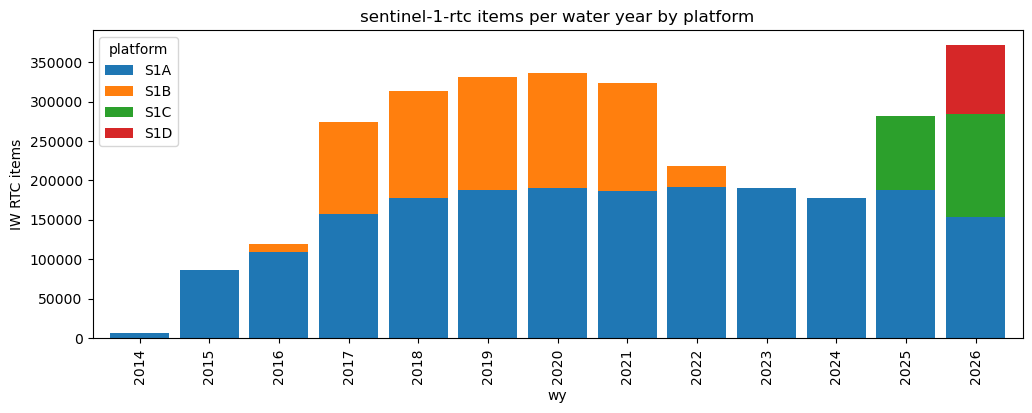

In [5]:
# --- summary table: items per water year x polarization x platform ---
rows = [{"wy": wy, "polgroup": pg, "platform": pf, "n_items": n}
        for (wy, pg, pf), n in sorted(counts.items())]
summary_df = pd.DataFrame(rows)
pivot_pol = summary_df.pivot_table(index="wy", columns="polgroup", values="n_items", aggfunc="sum", fill_value=0)
pivot_plat = summary_df.pivot_table(index="wy", columns="platform", values="n_items", aggfunc="sum", fill_value=0)
print("items per WY x polarization group:"); display(pivot_pol)
print("items per WY x platform:"); display(pivot_plat)
ax = pivot_plat.plot.bar(stacked=True, figsize=(12, 4), width=0.85)
ax.set_ylabel("IW RTC items"); ax.set_title("sentinel-1-rtc items per water year by platform")

Text(0.5, 0.98, 'sentinel-1-rtc IW true-footprint coverage (0.125° grid) by polarization group')

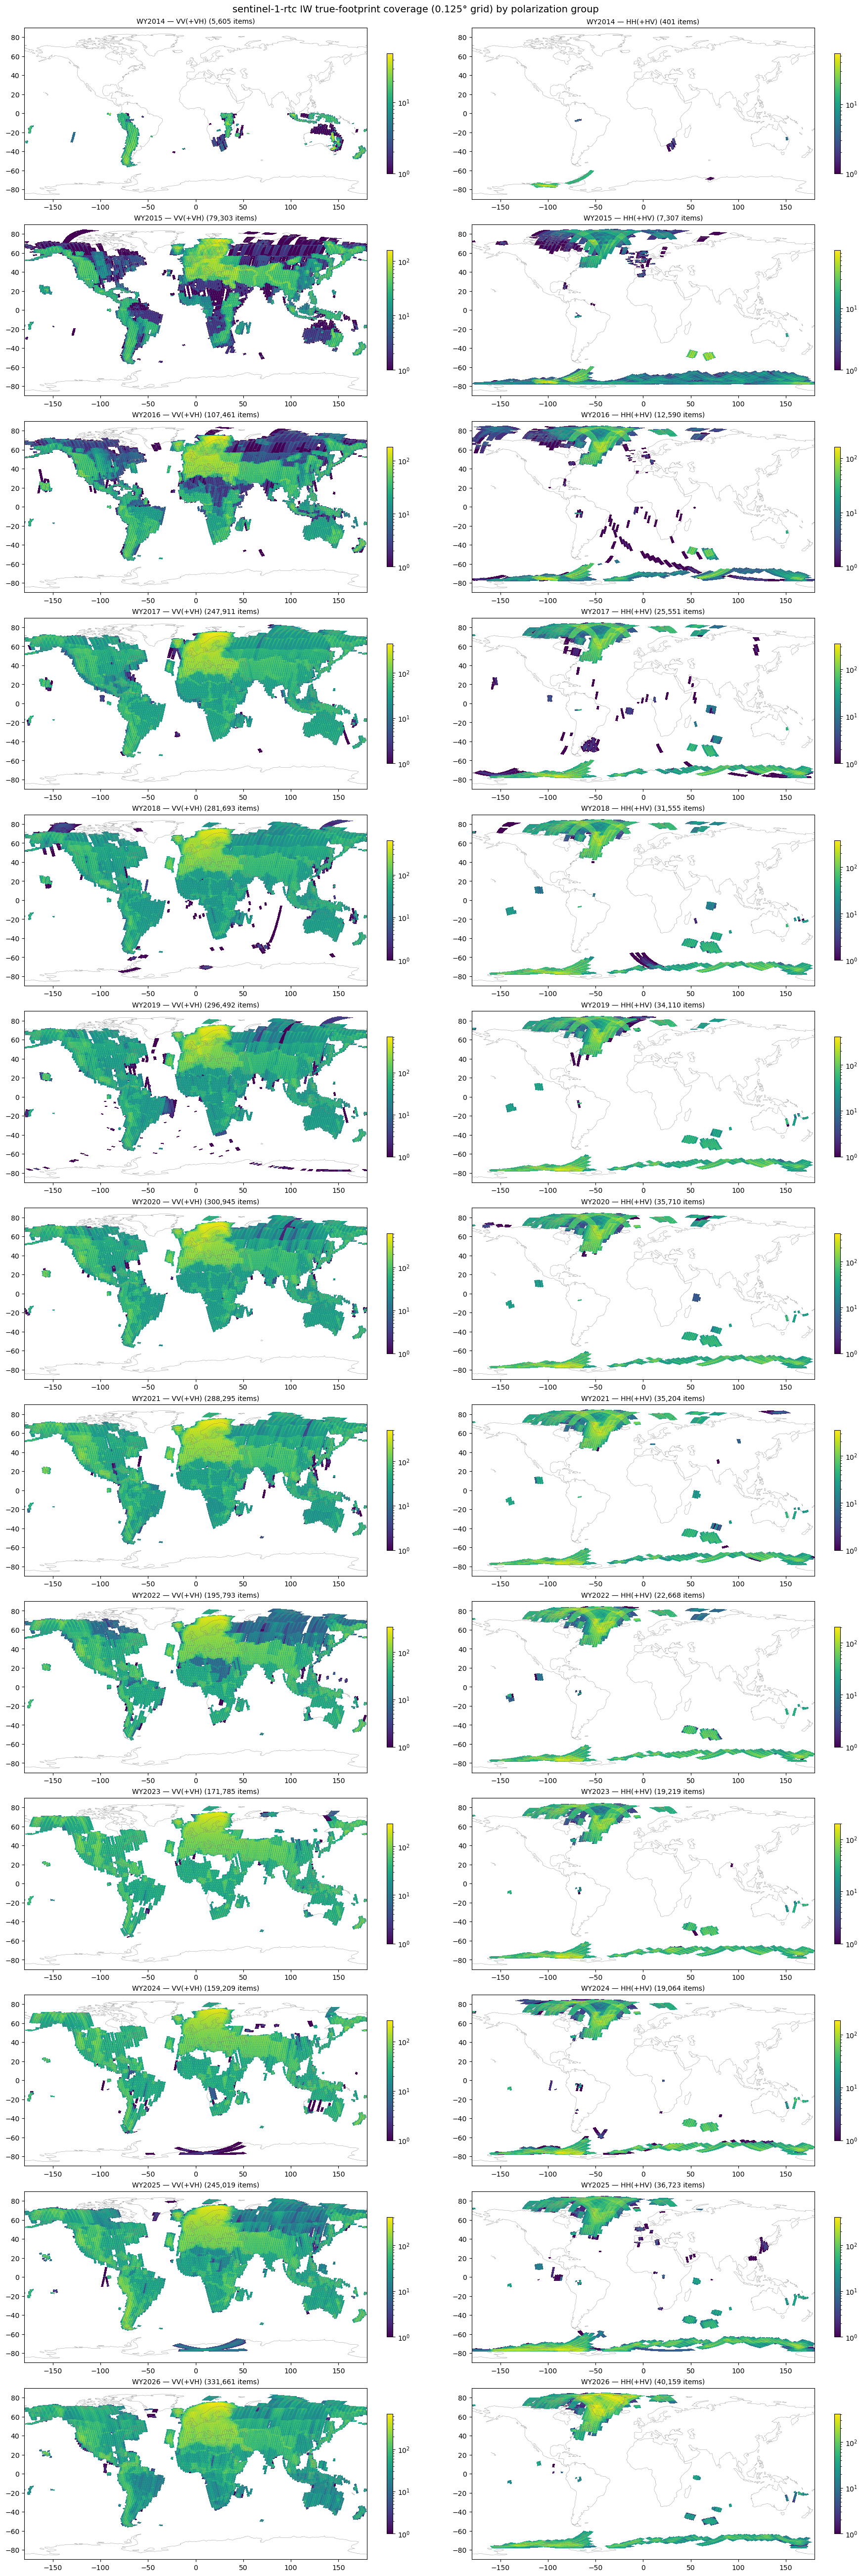

In [6]:
# --- global maps: true-footprint coverage, polarization groups x water years ---

def show_grid(ax, g, extent, cmap):
    """Masked float32 view keeps figure memory bounded; nearest keeps footprint edges crisp."""
    im = ax.imshow(np.ma.masked_equal(g, 0).astype(np.float32), extent=extent,
                   norm=mcolors.LogNorm(vmin=1, vmax=max(10, int(g.max()) or 10)),
                   cmap=cmap, interpolation="nearest", aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.7)

POLS = ["VV(+VH)", "HH(+HV)"]
fig, axs = plt.subplots(len(water_years), len(POLS),
                        figsize=(9 * len(POLS), 4.0 * len(water_years)),
                        squeeze=False, constrained_layout=True)
for i, wy in enumerate(water_years):
    for j, pg in enumerate(POLS):
        ax = axs[i, j]
        n = sum(v for (w, p, _), v in counts.items() if w == wy and p == pg)
        if (wy, pg) in grids_pol:
            show_grid(ax, grids_pol[(wy, pg)], [-180, 180, -90, 90], "viridis")
            world_gdf.plot(ax=ax, linewidth=0.3, color="gray")
        else:
            ax.text(0.5, 0.5, "no items", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
        ax.set_title(f"WY{wy} — {pg} ({n:,} items)", fontsize=10)
fig.suptitle("sentinel-1-rtc IW true-footprint coverage (0.125° grid) by polarization group",
             fontsize=14)


Text(0.5, 0.98, 'sentinel-1-rtc IW true-footprint coverage (0.125° grid) by platform')

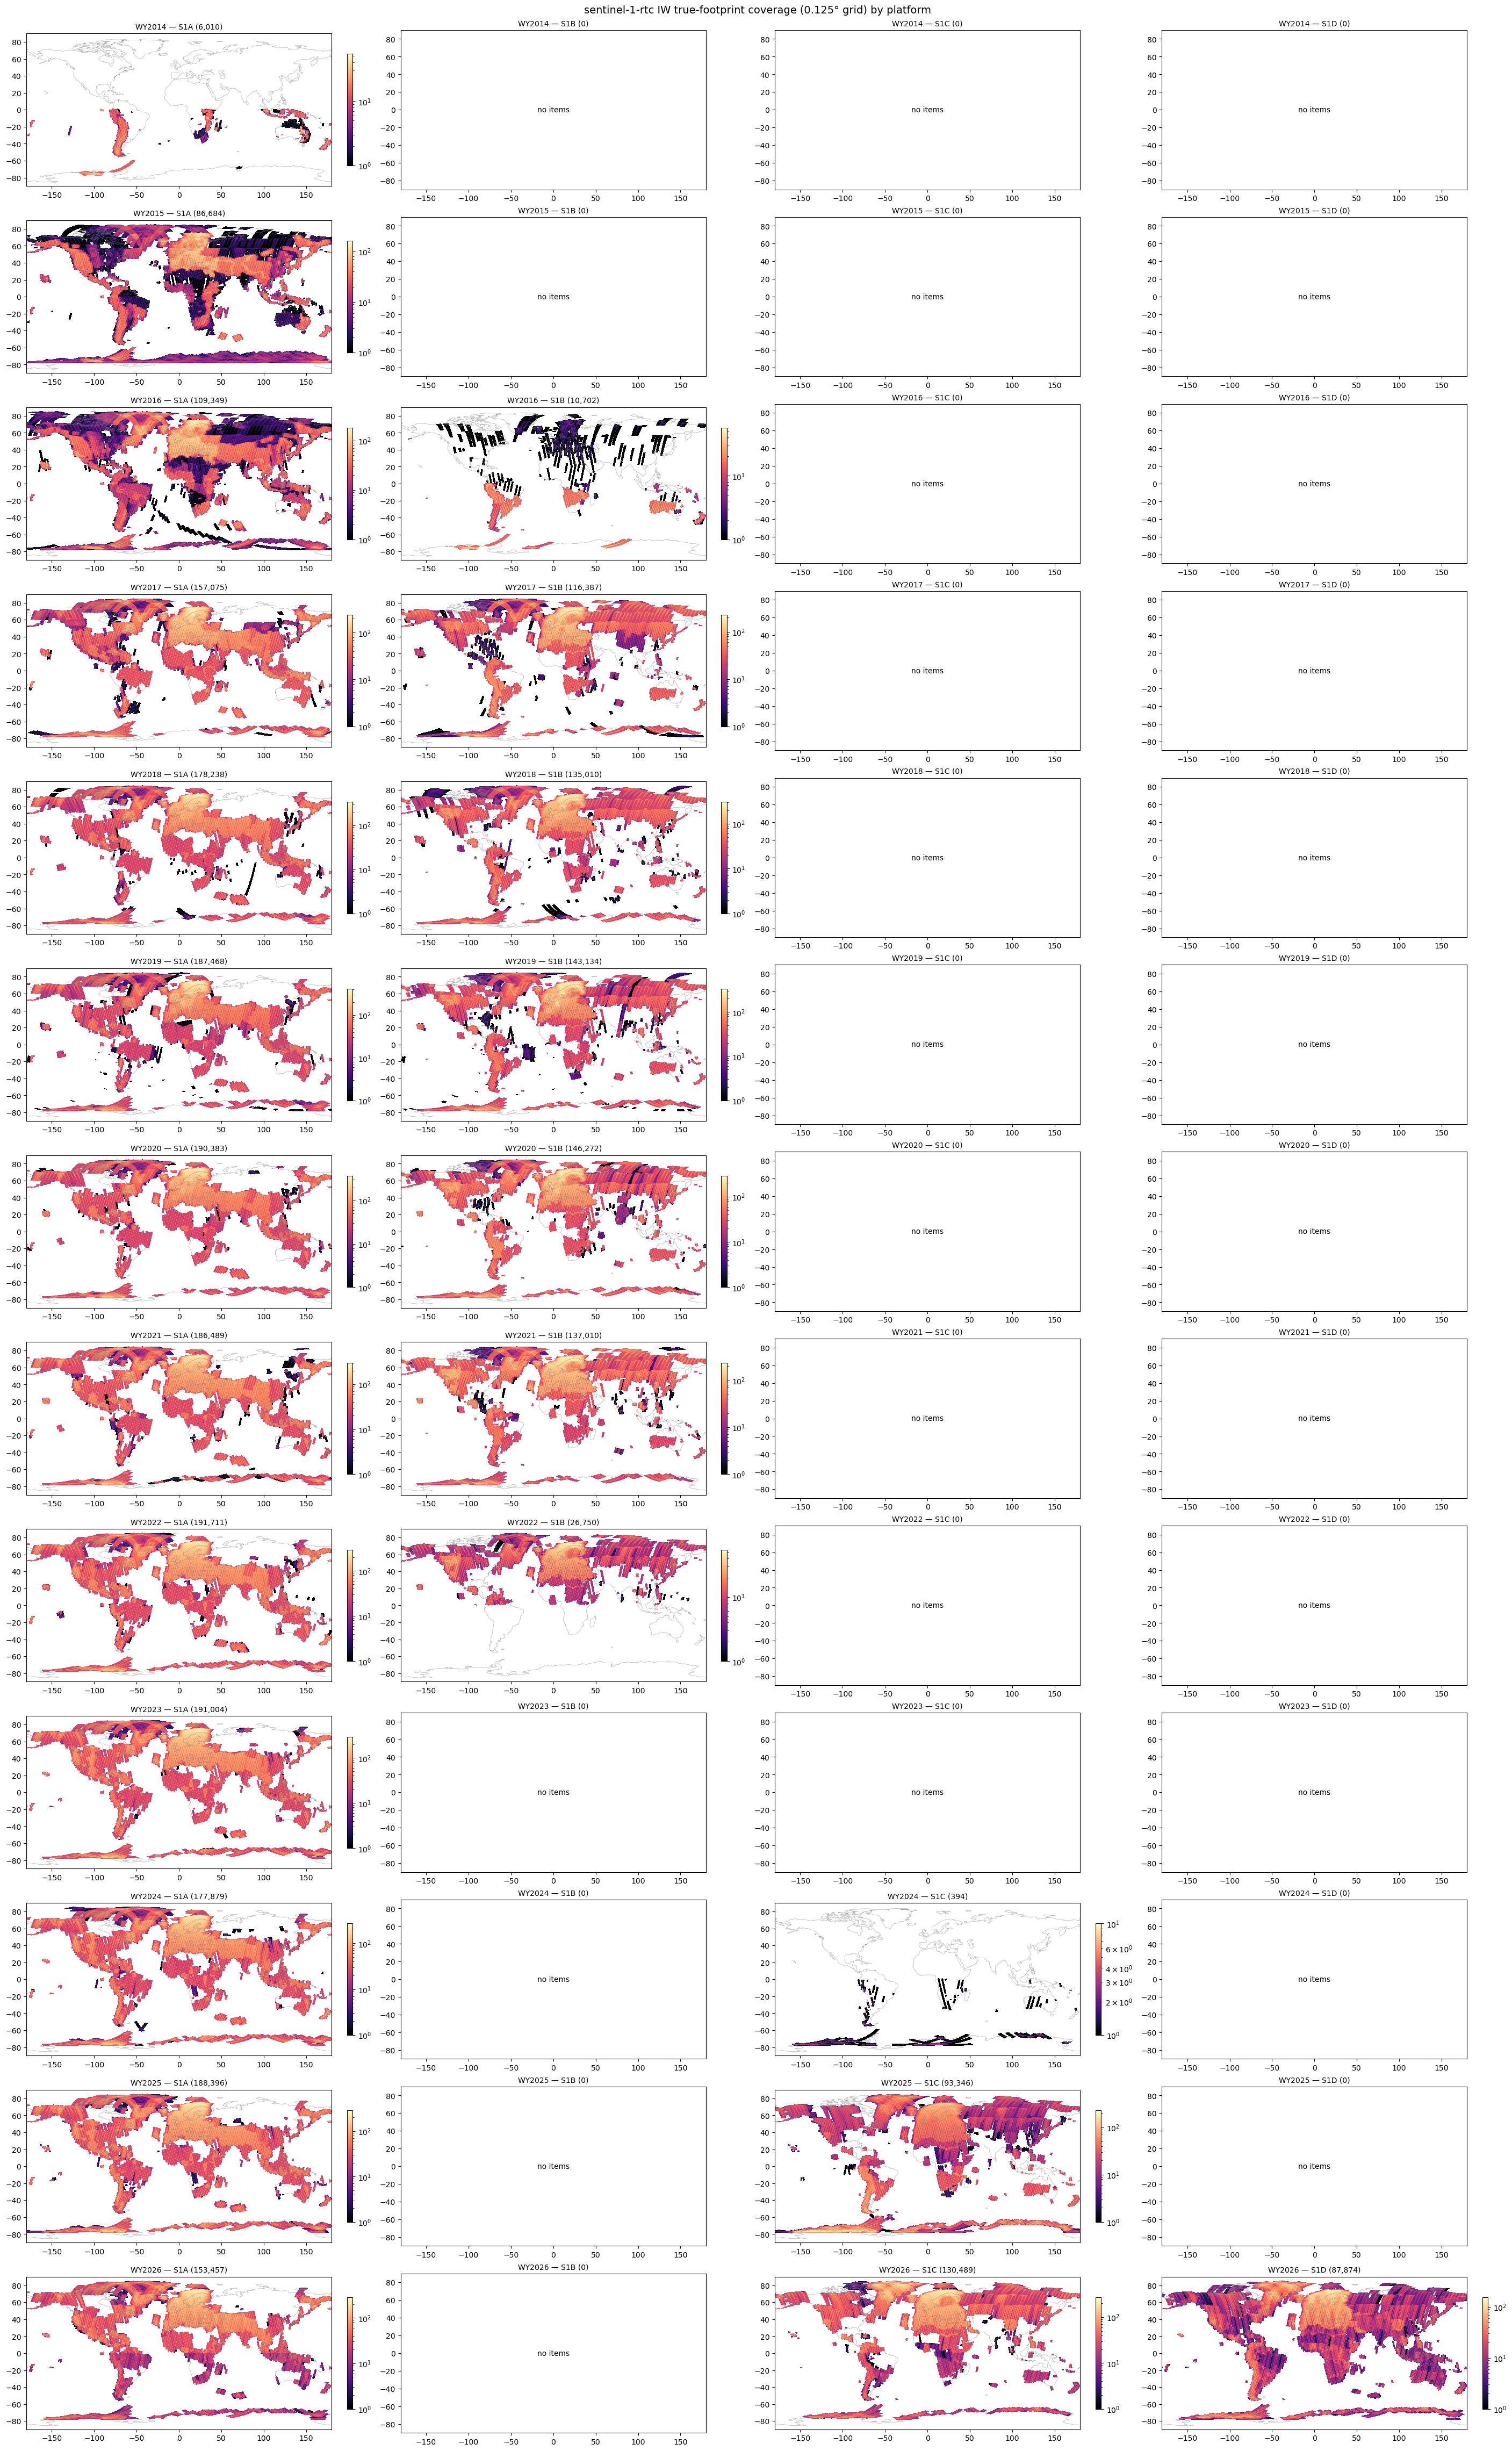

In [7]:
# --- global maps: true-footprint coverage, platforms x water years ---
platforms = sorted({k[1] for k in grids_plat})
fig, axs = plt.subplots(len(water_years), len(platforms),
                        figsize=(7 * len(platforms), 3.5 * len(water_years)),
                        squeeze=False, constrained_layout=True)
for i, wy in enumerate(water_years):
    for j, pf in enumerate(platforms):
        ax = axs[i, j]
        n = sum(v for (w, _, p), v in counts.items() if w == wy and p == pf)
        if (wy, pf) in grids_plat:
            show_grid(ax, grids_plat[(wy, pf)], [-180, 180, -90, 90], "magma")
            world_gdf.plot(ax=ax, linewidth=0.3, color="gray")
        else:
            ax.text(0.5, 0.5, "no items", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
        ax.set_title(f"WY{wy} — {pf} ({n:,})", fontsize=10)
fig.suptitle("sentinel-1-rtc IW true-footprint coverage (0.125° grid) by platform", fontsize=14)

polgroup,HH(+HV),VV(+VH)
wy,,
2015,1591,685
2016,3948,1086
2017,7284,2473
2018,8328,2907
2019,9006,2967
2020,9469,3004
2021,10669,2833
2022,6481,1640
2023,4816,1275


Text(0.5, 0.98, 'Raw footprint polygons (one month, Greenland window)')

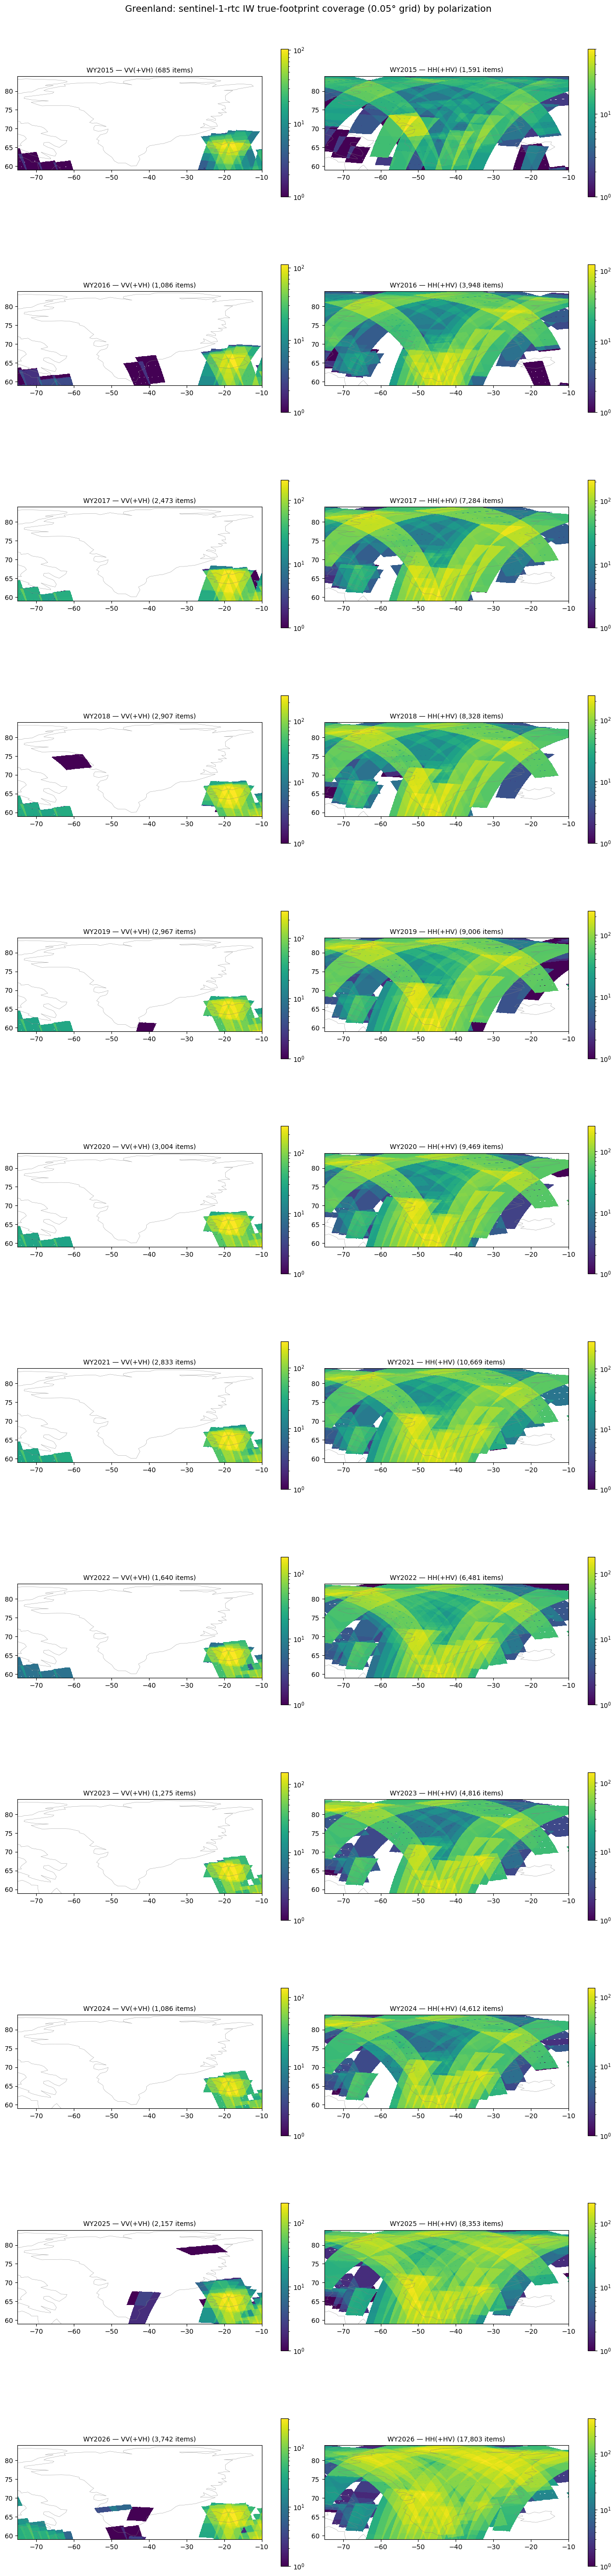

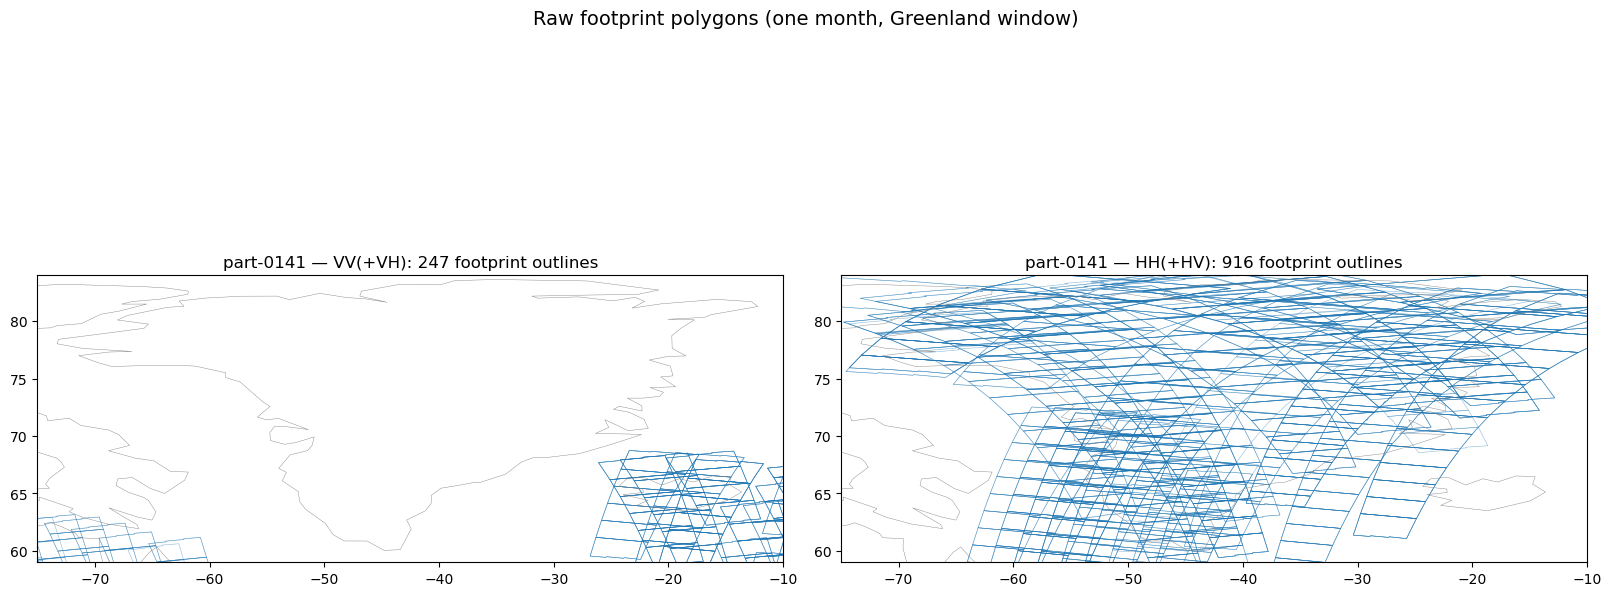

In [8]:
# --- Greenland zoom (grids accumulated in the main pass, 0.05° ~ 5.5 km) ---
gl_df = pd.DataFrame([{"wy": wy, "polgroup": pg, "n_items": n}
                      for (wy, pg), n in sorted(counts_gl.items())])
display(gl_df.pivot_table(index="wy", columns="polgroup", values="n_items",
                          aggfunc="sum", fill_value=0))

gl_extent = [GL["lon_min"], GL["lon_max"], GL["lat_min"], GL["lat_max"]]
gl_years = sorted({k[0] for k in grids_gl})
fig, axs = plt.subplots(len(gl_years), len(POLS), figsize=(6.5 * len(POLS), 4.6 * len(gl_years)),
                        squeeze=False, constrained_layout=True)
for i, wy in enumerate(gl_years):
    for j, pg in enumerate(POLS):
        ax = axs[i, j]
        if (wy, pg) in grids_gl:
            show_grid(ax, grids_gl[(wy, pg)], gl_extent, "viridis")
        else:
            ax.text(0.5, 0.5, "no items", ha="center", va="center", transform=ax.transAxes)
        world_gdf.plot(ax=ax, linewidth=0.3, color="gray")
        ax.set_xlim(gl_extent[0], gl_extent[1]); ax.set_ylim(gl_extent[2], gl_extent[3])
        ax.set_title(f"WY{wy} — {pg} ({counts_gl.get((wy, pg), 0):,} items)", fontsize=10)
fig.suptitle("Greenland: sentinel-1-rtc IW true-footprint coverage (0.05° grid) by polarization",
             fontsize=14)

# --- raw footprint OUTLINES for one recent month over Greenland: the actual polygons,
#     no gridding at all -- a direct look at what the coverage maps are counting ---
import geopandas as gpd
frag = fragments[-1]
tbl = pq.ParquetFile(fs.open(frag)).read(columns=COLS)
bb = tbl["bbox"].combine_chunks()
xmin, xmax = bb.field("xmin").to_numpy(), bb.field("xmax").to_numpy()
ymin, ymax = bb.field("ymin").to_numpy(), bb.field("ymax").to_numpy()
in_gl = ((xmax - xmin) <= 180) & ((xmax >= GL["lon_min"]) & (xmin <= GL["lon_max"])
         & (ymax >= GL["lat_min"]) & (ymin <= GL["lat_max"]))
pg = np.array([polgroup(p) for p in tbl["sar:polarizations"].to_pylist()], object)
geoms = shapely.from_wkb(tbl["geometry"].to_numpy(zero_copy_only=False), on_invalid="ignore")

fig, axs = plt.subplots(1, len(POLS), figsize=(8 * len(POLS), 8), constrained_layout=True)
for ax, want in zip(np.atleast_1d(axs), POLS):
    sel = [g for g, keep, p in zip(geoms, in_gl, pg) if keep and g is not None and p == want]
    if sel:
        gpd.GeoSeries(sel, crs=4326).boundary.plot(ax=ax, linewidth=0.4, alpha=0.5)
    world_gdf.plot(ax=ax, linewidth=0.3, color="gray")
    ax.set_xlim(gl_extent[0], gl_extent[1]); ax.set_ylim(gl_extent[2], gl_extent[3])
    ax.set_title(f"{frag.split('/')[-1][:9]} — {want}: {len(sel)} footprint outlines")
fig.suptitle("Raw footprint polygons (one month, Greenland window)", fontsize=14)

## Conclusions (fill in after running; hard facts already established below)

**Established during v10 validation (2026-07, spot checks against the live catalog):**
- The `sentinel-1-rtc` collection is **IW-mode only** (`sar:instrument_mode = ['IW']`); EW
  acquisitions are not in the collection at all. Availability differences are therefore a
  **polarization** question, not a mode question.
- **Canadian Arctic islands** are covered by **IW HH+HV** items — present in the catalog but
  invisible to our `vv`-based pipeline.
- **Greenland interior** Looks like mostly HH/HV......
- **Platform turnover**: S1B failed Dec 2021; S1C and S1D entered service 2025+; the
  **July 2026 partition contains only S1C and S1D items** — S1A appears to have wound down.
  Expect the platform heatmaps to show: A+B (2015–2021) → A alone (2022–2024) → A+C → C+D.

**To fill in from the figures above:**
- Per-WY polarization mix trends (is HH+HV shrinking/growing? where?)
- When VV+VH coverage appears over Greenland margins vs interior, and at what density
- Whether S1C/S1D changed the polarization plan over high latitudes

**Greenland inclusion (future work):** we keep Greenland excluded for now.For the longer record, HH(+HV) processing would be required —
wet-snow detection on ice sheets with S1 backscatter is established in the literature (e.g.
https://tc.copernicus.org/articles/16/625/2022/), but our runoff-onset algorithm (per-orbit
backscatter minimum) would need validation for HH polarization and for firn/ice-sheet conditions
before adding a polarization-aware processing path (e.g. `bands` per region, HH fallback where VV
is absent). Would have to figure out how to add this too in the select_tiles_to_process.ipynb notebook.